In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import linalg as la
from tqdm import trange
from dataclasses import dataclass, field


from koala.flux_finder import ujk_from_fluxes, fluxes_from_ujk
import mpmath
from dimer_models.kasteleyn import (
    kasteleyn_matrix,
    fast_pfaffian_as_mpmath,
    generate_kasteleyn_orientation,
    generate_torus_orientations,
    find_omega,
)
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import plotting as pl
from koala.lattice import Lattice, INVALID
from koala import example_graphs as eg
from koala import pachner_moves

# mpmath.mp.dps = 50
import pickle

from dimer_models.lattice_generation import bipartite_squarefull

In [31]:
def dimer_dimer_prob(dimerisations, chosen_edges):
    e = np.array([dimerisations[:, x] == True for x in chosen_edges])
    return np.average(e.prod(axis=0))

In [ ]:
try:
    lattice
except NameError:
    rng = np.random.default_rng()
    lattice = bipartite_squarefull(40)
    lattice = gu.tutte_embedding(lattice)


pos = np.array([[0.25, 0.25], [0.75, 0.75]])
chosen_vertices = [np.argmin(la.norm(lattice.vertices.positions - p, axis=1)) for p in pos]

# these test dimer correlations
randomly_chosen_edges = np.array([rng.choice(range(lattice.n_edges), 3, False) for _ in range(10)])

chosen_plaquettes = lattice.vertices.adjacent_plaquettes[chosen_vertices][:, -1]
randomly_chosen_edges

array([[40, 42, 47],
       [50, 59, 14],
       [17, 55, 19],
       [41, 42, 16],
       [ 0, 27, 55],
       [13, 38,  8],
       [24, 15, 10],
       [39, 21, 23],
       [26, 10,  1],
       [18, 30,  3]])

In [33]:
# del lattice

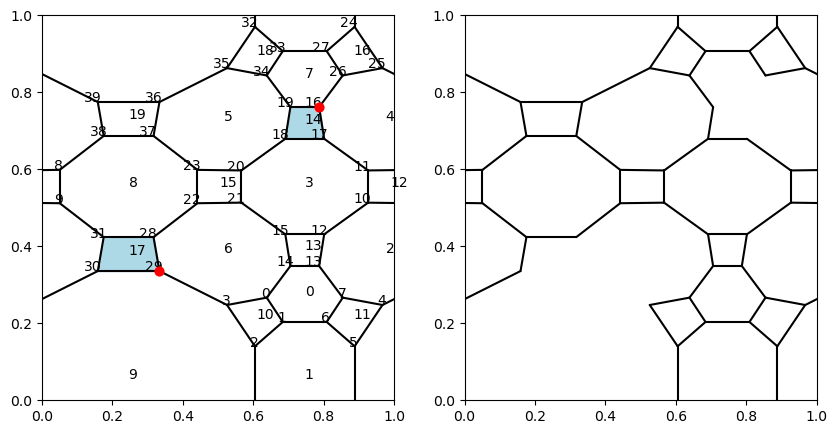

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


reduced_lattice = gu.remove_vertices(lattice, chosen_vertices)

pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(reduced_lattice, ax=ax[1])
pl.plot_plaquettes(
    lattice, subset=chosen_plaquettes, zorder=-10, color_scheme=["lightblue"], ax=ax[0]
)

pl.plot_vertex_indices(lattice, ax=ax[0])
pl.plot_plaquette_indices(lattice, ax=ax[0])

chosen_positions = lattice.vertices.positions[chosen_vertices]
ax[0].scatter(*chosen_positions.T, zorder=10, c="r", s=40)

plt.show()

In [ ]:
# brute force dimerisations
dimerisations = gu.dimerise(lattice, -1)
monomer_dimerisations = gu.dimerise(reduced_lattice, -1)
dimer_probabilities = np.average(dimerisations, axis=0)
dimer_dimer_probabilities = np.array(
    [dimer_dimer_prob(dimerisations, c) for c in randomly_chosen_edges]
)
n_dimerisations = dimerisations.shape[0]
n_monomer_dimerisations = monomer_dimerisations.shape[0]

print(f"n_dimers: {n_dimerisations}\n")
print(f"n_monomer_dimerisations: {n_monomer_dimerisations}\n")
print(f"monomer_probabilities: {n_monomer_dimerisations / n_dimerisations}\n")
print(f"dimer_probabilities\n{dimer_probabilities}\n")
print(f"dimer_dimer_probabilities\n{dimer_dimer_probabilities}\n")

n_dimers: 2905

n_monomer_dimerisations: 334

monomer_probabilities: 0.11497418244406196

dimer_probabilities
[0.20413081 0.18726334 0.18726334 0.18726334 0.18726334 0.21824441
 0.21824441 0.21824441 0.19311532 0.17969019 0.20413081 0.21824441
 0.19311532 0.17969019 0.16557659 0.16557659 0.17969019 0.19311532
 0.19311532 0.17969019 0.38347676 0.41239243 0.42203098 0.39827883
 0.42203098 0.41239243 0.38347676 0.39827883 0.38932874 0.41755594
 0.39518072 0.41755594 0.37314974 0.40860585 0.37314974 0.43958692
 0.37314974 0.43958692 0.37314974 0.40860585 0.39518072 0.41755594
 0.38932874 0.41755594 0.42203098 0.39827883 0.38347676 0.41239243
 0.39759036 0.42271945 0.39759036 0.40929432 0.41239243 0.38347676
 0.39827883 0.42203098 0.39759036 0.40929432 0.39759036 0.42271945]

dimer_dimer_probabilities
[0.1394148  0.01170396 0.01790017 0.         0.00550775 0.0151463
 0.         0.13425129 0.01204819 0.00481928]



First check that the number of dimerisations is right

In [ ]:
# compute the four kasteleyn matrices
initial_ujk = generate_kasteleyn_orientation(lattice)
orientations = generate_torus_orientations(lattice, initial_ujk)
kasteleyn_matrices = np.array([kasteleyn_matrix(lattice, o) for o in orientations])

# find inverses and pfaffians
pfaffians = np.array([fast_pfaffian_as_mpmath(k) for k in kasteleyn_matrices])

# find n_dimerisations from pfaffian
omega = find_omega(pfaffians)
n_dimerisations_pfaff = int(mpmath.nint(abs(sum(omega * pfaffians) / 2)))


print(n_dimerisations_pfaff)
assert n_dimerisations - n_dimerisations_pfaff == 0, f"{n_dimerisations - n_dimerisations_pfaff}"
print("counting dimerisations correctly")
# check its all correct
for j, k in enumerate(kasteleyn_matrices):
    assert np.all(k + k.T == 0)

2905
counting dimerisations correctly


In [ ]:
# find probabilities per edge
inverses = np.array([la.inv(k) for k in kasteleyn_matrices])
inverse_numerator = np.sum(
    (omega * pfaffians)[:, None, None] * inverses * kasteleyn_matrices, axis=0
)
inverse_denominator = np.sum(omega * pfaffians)
probs_k = np.abs((inverse_numerator / inverse_denominator)[*lattice.edges.indices.T]).astype(float)


assert np.allclose(probs_k - dimer_probabilities, 0)
print("counting probabilities correctly")

counting probabilities correctly


In [ ]:
multi_probabilities = []
for edges in randomly_chosen_edges:
    verts = lattice.edges.indices[edges]
    kasteleyn_products = np.prod(kasteleyn_matrices[:, *verts.T], axis=1)

    slice = np.ix_(verts.flatten(), verts.flatten())
    inverse_chunk = inverses[:, *slice]
    pfaffians_chunk = np.array([fast_pfaffian_as_mpmath(k) for k in inverse_chunk])
    numerator = np.sum(omega * pfaffians * pfaffians_chunk * kasteleyn_products)

    multi_probabilities.append(np.abs(numerator / inverse_denominator))

assert np.allclose((multi_probabilities - dimer_dimer_probabilities).astype(float), 0)

print("counting dimer-dimer correlations correctly")

counting dimer-dimer correlations correctly


In [ ]:
# compute the four kasteleyn matrices with monomer fluxes
monomer_fluxes = np.array([-1] * lattice.n_plaquettes)
monomer_fluxes[chosen_plaquettes] *= -1
monomer_ujk = ujk_from_fluxes(lattice, monomer_fluxes, initial_ujk)


monomer_orientations = generate_torus_orientations(lattice, monomer_ujk)
kasteleyn_tilde_matrices = np.array([kasteleyn_matrix(lattice, o) for o in monomer_orientations])


pfaffians_tilde = []
inverses_tilde = []
for k in kasteleyn_tilde_matrices:
    p = fast_pfaffian_as_mpmath(k)
    if abs(p) > 1e-12:
        pfaffians_tilde.append(p)
        inverses_tilde.append(la.inv(k))
    else:
        pfaffians_tilde.append(0)
        inverses_tilde.append(np.zeros_like(k))

pfaffians_tilde = np.array(pfaffians_tilde)
inverses_tilde = np.array(inverses_tilde)

# find n_dimerisations from pfaffian

inverses_tilde_restricted = inverses_tilde[:, *np.ix_(chosen_vertices, chosen_vertices)]
inverses_tilde_pfaffs = np.array([fast_pfaffian_as_mpmath(k) for k in inverses_tilde_restricted])
omega_tilde = find_omega(inverses_tilde_pfaffs * pfaffians_tilde)
monomer_numerator = omega_tilde * inverses_tilde_pfaffs * pfaffians_tilde
n_monomers_pfaff = int(mpmath.nint(mpmath.fabs(sum(monomer_numerator) / 2)))

if np.any(pfaffians_tilde == 0):
    print("one pfaffian vanishes")
    print(np.round(pfaffians_tilde.astype(int)))
print(n_monomers_pfaff, n_monomer_dimerisations, "\n\n")
try:
    assert (n_monomers_pfaff - n_monomer_dimerisations) == 0, (
        f"{n_monomers_pfaff - n_monomer_dimerisations}"
    )

except AssertionError as e:
    omega_options = np.ones([4, 4]) - 2 * np.eye(4)
    for omega_tilde in omega_options:
        monomer_numerator = omega_tilde * inverses_tilde_pfaffs * pfaffians_tilde
        n_monomers_pfaff = int(mpmath.nint(mpmath.fabs(sum(monomer_numerator) / 2)))
        print(n_monomers_pfaff, n_monomer_dimerisations)

    assert False, f"{n_monomers_pfaff - n_monomer_dimerisations}"

print("counting monomers correctly")

334 334 


counting monomers correctly


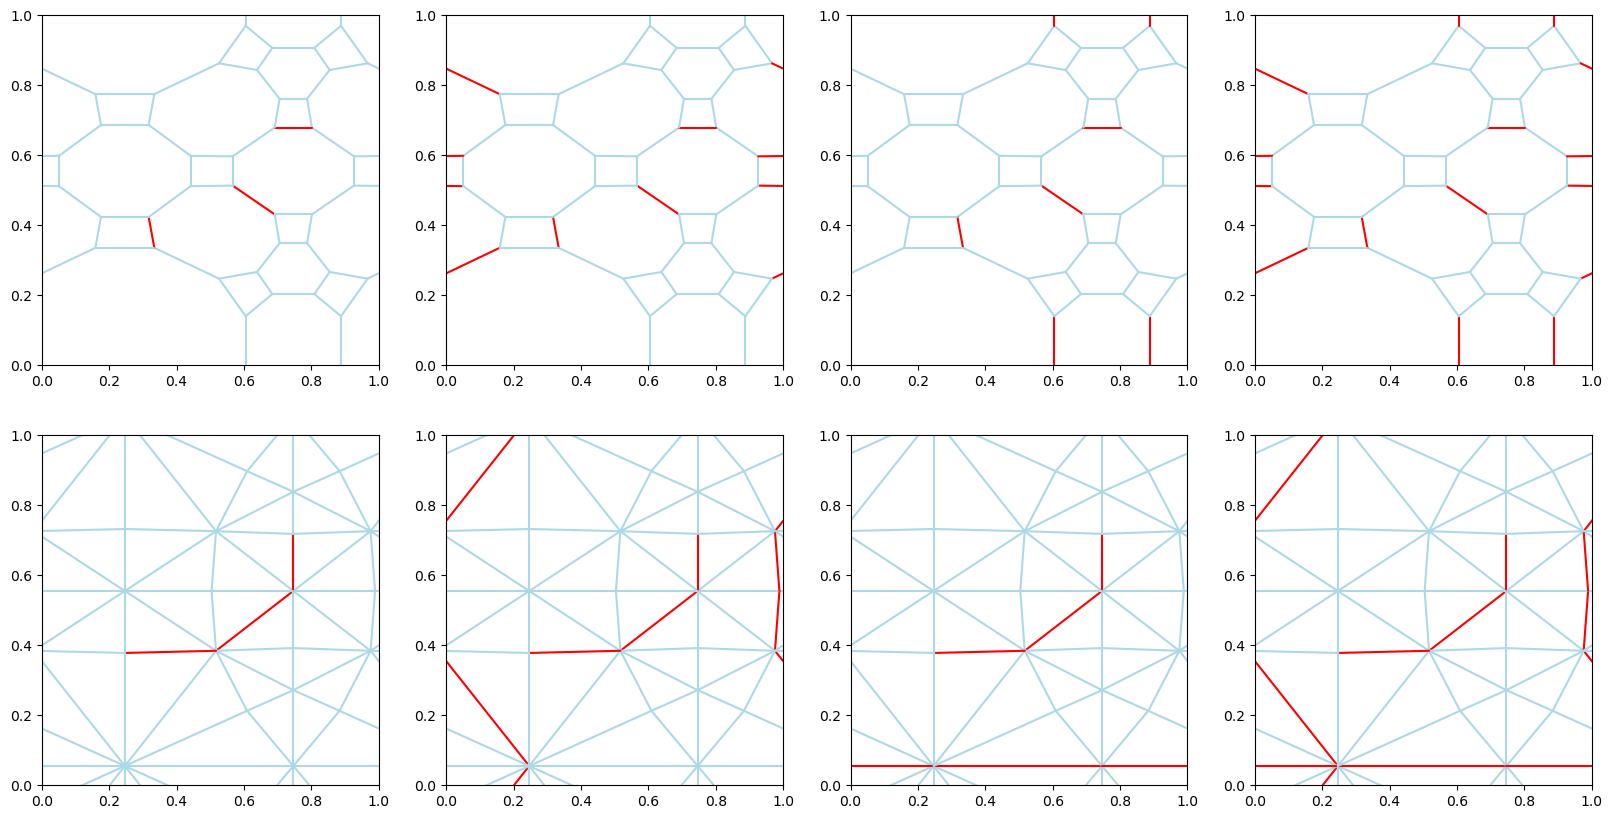

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for ii in range(4):
    ujk_diff = 1 - (monomer_orientations[ii] == initial_ujk)
    pl.plot_edges(lattice, ax=ax[0, ii], labels=ujk_diff, color_scheme=["lightblue", "red"])
    pl.plot_edges(
        gu.make_dual(lattice, reg_steps=0),
        ax=ax[1, ii],
        labels=ujk_diff,
        color_scheme=["lightblue", "red"],
    )

In [41]:
del lattice